# VASICEK ONE-FACTOR MODEL

In [22]:
from matplotlib import pyplot as plt
import numpy as np
import scipy

## Calibrating the Model

In [23]:
T = np.linspace(0.25, 10, 40)   # 3 months to 10 years

In [24]:
def yield_curve(T):
    return 0.02 + 0.015*(1 - np.exp(-0.5*T))

In [25]:
P_market = np.exp(-yield_curve(T) * T)

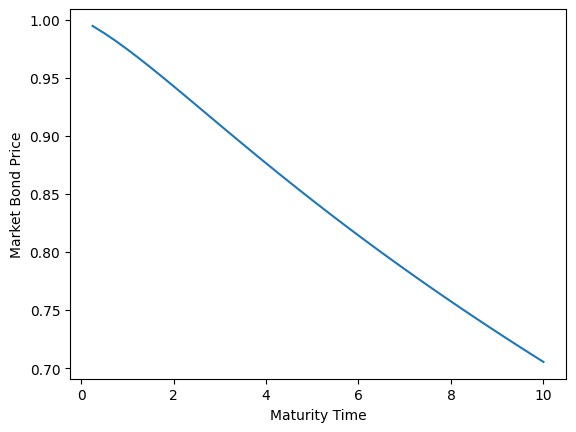

In [26]:
plt.plot(T, P_market)
plt.xlabel('Maturity Time')
plt.ylabel('Market Bond Price')
plt.show()

In [27]:
def vasicek_bond_price(T, alpha, mu, sigma, r0):
    B = (1 - np.exp(-alpha * T)) / alpha
    
    A = np.exp(
        (mu - sigma**2/(2*alpha**2)) * (B - T)
        - (sigma**2/(4*alpha)) * B**2
    )
    
    return A * np.exp(-B * r0)

Continuously compounded interest:

$\frac{dP}{P} = r(s)ds$

$ ln|P_T| - ln|P_0| = \int_0^T r(s)ds$

$ P(0) = e^{- \int_0^T r(s) ds}$

But if we define the average interest rate over the time period,

$\overline{r} = \frac{1}{T} \int_0^T r(s) ds$

then it is evaluated using

$-ln|P_0|/T = \overline{r}$

In [28]:
def model_yield(T, alpha, mu, sigma, r0):
    P = vasicek_bond_price(T, alpha, mu, sigma, r0)
    return -np.log(P) / T

In [29]:
def objective(params, T, y_market):
    alpha, mu, sigma, r0 = params
    y_model = model_yield(T, alpha, mu, sigma, r0)
    return np.mean((y_model - y_market)**2)

In [30]:
init = [0.5, 0.05, 0.05, 0.03]

bounds = [
    (1e-3, 2.0),   # alpha
    (0.0, 0.1),    # mu
    (1e-3, 0.3),   # sigma
    (0.0, 0.1)     # r0
]

In [31]:
from scipy.optimize import minimize

y_market = yield_curve(T)

res = minimize(objective, init, args=(T, y_market), bounds=bounds)

alpha_fit, mu_fit, sigma_fit, r0_fit = res.x

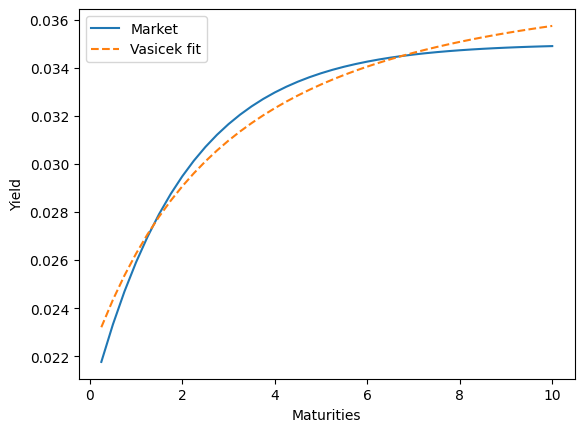

In [32]:
y_fit = model_yield(T, alpha_fit, mu_fit, sigma_fit, r0_fit)

plt.plot(T, y_market, label='Market')
plt.plot(T, y_fit, '--', label='Vasicek fit')
plt.xlabel('Maturities')
plt.ylabel('Yield')
plt.legend()

Vasicek just tries its best to recover the market observables. It can never exactly match the market at a given time.

In [33]:
alpha_fit, mu_fit, sigma_fit, r0_fit

(0.49983234825561507,
 0.04371268047400568,
 0.050913481771609724,
 0.02192358347323756)

## PDE Solver

In [34]:
T = 1 #maturity time

#params in vasicek model
alpha = 0.5

mu = 0.05

sig = 0.01

rmin = -0.4

rmax = 0.4

## Load in Chebyshev Polynomials and Match to Terminal Condition

In [35]:
n = 50 #grid resolution

diff = np.loadtxt('diffmatrix100.txt')[0:n,0:n]

chebyshevs = []
for i in range(0, n):
    chebyshevs.append(scipy.special.chebyt(i))

In [36]:
# tau array

tau = np.linspace(0, T, int(T/10**-3 + 1))
dtau = tau[1:] - tau[0:-1]

# solution array

c = np.zeros((len(tau), n))

#match to terminal condition

#coefficient of T_0 matched to unity at tau = 0!
c[0,0] = 1.


In [37]:
# transform to two numerical coordinates

def xnum_to_r(xnum):
    return rmax + (xnum - 1.)*((rmax - rmin)/2) 

In [38]:
# functions to plot data

xplot = np.linspace(-1,1,101)

def calc_u(c,x):
    sum = 0.0
    for i in range(len(c)):
        sum = sum + c[i]*chebyshevs[i](x)
    return sum

def plot_frame(tau_index):

    #left part
  
    plt.plot(xnum_to_r(xplot), calc_u(c[tau_index,:], xplot), c='blue')
       
    plt.title('p(x) at '+r'$\tau=$ '+str(tau[tau_index]))
    plt.ylabel(r'$p$')
    plt.xlabel(r'$x$')
    plt.show()



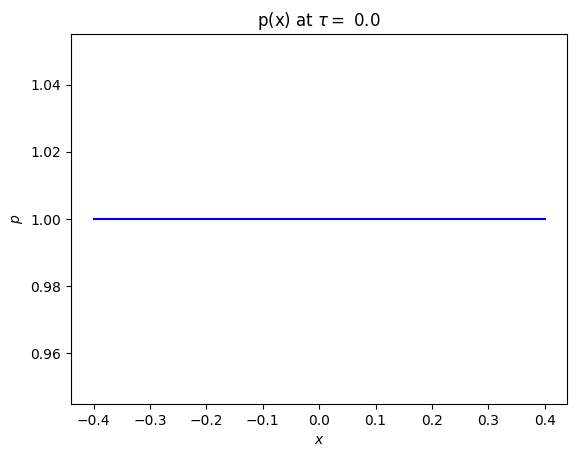

In [39]:
plot_frame(0)

## Method of Lines Solution with SDIRK

In [40]:
a11 = 4.772644573858262e-01
c1 = a11

a21 = -1.970525884150017e-01
a22 = 4.763634284595835e-01
c2 = a21 + a22

a31 = -3.476744303729656e-02
a32 = 6.330518073354831e-01
a33 = 1.936343100750279e-01
c3 = a31 + a32 + a33

a41 = 9.677976685787021e-02
a42 = -1.935335264665350e-01
a43 = -2.076229458004729e-04
a44 = 1.595722048494314e-01
c4 = a41 + a42 + a43 + a44

a51 = 1.625272318198749e-01
a52 = -2.496725135473825e-01
a53 = -4.590799720417948e-02
a54 = 3.657947640085904e-01
a55 = 2.557528383076989e-01
c5 = a51 + a52 + a53 + a54 + a55

a61 = -7.076031971712624e-03
a62 = 8.462998548602952e-01
a63 = 3.440200169250181e-01
a64 = -7.209260545488652e-02
a65 = -2.154923319808753e-01
a66 = 1.043410976221611e-01
c6 = a61 + a62 + a63 + a64 + a65 + a66


a71 = 1.768579351797444e-03
a72 = 7.799600131275149e-02
a73 = 3.033332775645574e-01
a74 = 2.131608067328356e-01
a75 = 3.517693203190381e-01
a76 = -3.815458943865381e-01
a77 = 4.335179091055582e-01
c7 = a71 + a72 + a73 + a74 + a75 + a76 + a77

a81 = 0.000000000000000e+00
a82 = 2.273235341055902e-01
a83 = 3.084158379801177e-01
a84 = 1.572634195730069e-01
a85 = 2.435511371522748e-01
a86 = -1.209536267328315e-01
a87 = -8.026784733998993e-02
a88 =  2.646675452618318e-01
c8 = a81 + a82 + a83 + a84 + a85 + a86 + a87 + a88

b1 = a81
b2 = a82
b3 = a83
b4 = a84
b5 = a85
b6 = a86
b7 = a87
b8 = a88

In [41]:
def calc_T_matrix(dim, xcol):
    T = np.zeros(dim)
    for i in range(0,dim):
        T[i] = chebyshevs[i](xcol)
    return T

#Gauss-Lobatto Nodes
xcol = np.cos(np.pi*np.linspace(1, n-2, int(n-2))/(n-1))

#collocation matrices
Tcol = np.zeros((len(xcol),n))
for i in range(0, len(xcol)):
    Tcol[i,:] = calc_T_matrix(n, xcol[i])
    
Tdiffcol = np.matmul(Tcol, diff)
Tdiff2col = np.matmul(np.matmul(Tcol, diff), diff)

In [42]:
def vasicek_analytical(tau, alpha, mu, sig, r):
    q  = (1 - np.exp(-alpha*tau))/alpha
    f = (q - tau)*(mu - sig**2/(2*alpha**2)) - sig**2*q**2/(4*alpha)

    return np.exp(f - q*r)

In [43]:
def calc_K(c, tau_inp, dtau_inp, K1, K2, K3, K4, K5, K6, K7, key):

    dtau = dtau_inp

    if key == 1:
        tau = tau_inp + dtau*c1
    elif key == 2:
        tau = tau_inp + dtau*c2
    elif key == 3:
        tau = tau_inp + dtau*c3
    elif key == 4:
        tau = tau_inp + dtau*c4
    elif key == 5:
        tau = tau_inp + dtau*c5
    elif key == 6:
        tau = tau_inp + dtau*c6
    elif key == 7:
        tau = tau_inp + dtau*c7
    elif key == 8:
        tau = tau_inp + dtau*c8
    

    L = np.zeros((n, n))
    R = np.zeros((n, n))
    J = np.zeros(n)
    
    #prepare the matrices
    
###################################################################################################
  
    #PDE

    rcol = xnum_to_r(xcol)
    L[0:len(xcol),:] = Tcol 
    R[0:len(xcol),:] = (1/2)*sig**2*(2/(rmax - rmin))**2*Tdiff2col + (alpha*(mu - rcol)*(2/(rmax - rmin))*Tdiffcol.T).T + ((-rcol)*Tcol.T).T
    
    row_count = len(xcol)    
        
#############################################################################################################################################
    
    #boundary conditions

    #boundary conditions
        
    Bt = (1. - np.exp(-alpha*tau))/alpha
    scale = 2./(rmax - rmin)

    # left boundary: dp/dr + B*p = 0
    R[row_count, :] = scale*calc_T_matrix(n, -1.) @ diff + Bt*calc_T_matrix(n, -1.)
    J[row_count] = 0.
    row_count += 1

    # right boundary
    R[row_count, :] = scale*calc_T_matrix(n, +1.) @ diff + Bt*calc_T_matrix(n, +1.)
    J[row_count] = 0.
    row_count += 1

    '''
    #left cell
    R[row_count, :] = calc_T_matrix(n, -1.)
    J[row_count] =  vasicek_analytical(tau, alpha, mu, sig, rmin)

    row_count = row_count + 1

    #right cell
    R[row_count, :] = calc_T_matrix(n, +1.)
    J[row_count] = vasicek_analytical(tau, alpha, mu, sig, rmax)

    row_count = row_count + 1
    '''
    
####################################################################################################################################################
    
    if key == 1:
        Lbar = L - R*(dtau)*(a11)
        Rbar = np.matmul(R, c) - J
        K1 = np.linalg.solve(Lbar,Rbar)
        return K1
    elif key == 2:
        Lbar = L - R*(dtau)*(a22)
        Rbar = np.matmul(R, c + dtau*K1*a21) - J
        K2 = np.linalg.solve(Lbar,Rbar)
        return K2
    elif key == 3:
        Lbar = L - R*(dtau)*(a33)
        Rbar = np.matmul(R, c + dtau*K1*a31 + dtau*K2*a32) - J
        K3 = np.linalg.solve(Lbar,Rbar)
        return K3
    elif key == 4:
        Lbar = L - R*(dtau)*(a44)
        Rbar = np.matmul(R, c + dtau*K1*a41 + dtau*K2*a42 + dtau*K3*a43) - J
        K4 = np.linalg.solve(Lbar,Rbar)
        return K4
    elif key == 5:
        Lbar = L - R*(dtau)*(a55)
        Rbar = np.matmul(R, c + dtau*K1*a51 + dtau*K2*a52 + dtau*K3*a53 + dtau*K4*a54) - J
        K5 = np.linalg.solve(Lbar,Rbar)
        return K5
    elif key == 6:
        Lbar = L - R*(dtau)*(a66)
        Rbar = np.matmul(R, c + dtau*K1*a61 + dtau*K2*a62 + dtau*K3*a63 + dtau*K4*a64 + dtau*K5*a65) - J
        K6 = np.linalg.solve(Lbar,Rbar)
        return K6
    elif key == 7:
        Lbar = L - R*(dtau)*(a77)
        Rbar = np.matmul(R, c + dtau*K1*a71 + dtau*K2*a72 + dtau*K3*a73 + dtau*K4*a74 + dtau*K5*a75 + dtau*K6*a76) - J
        K7 = np.linalg.solve(Lbar,Rbar)
        return K7
    elif key == 8:
        Lbar = L - R*(dtau)*(a88)
        Rbar = np.matmul(R, c + dtau*K1*a81 + dtau*K2*a82 + dtau*K3*a83 + dtau*K4*a84 + dtau*K5*a85 + dtau*K6*a86 + dtau*K7*a87) - J
        K8 = np.linalg.solve(Lbar,Rbar)
        return K8
        

In [44]:
#Calculate Data for all Times

for i in range(0, len(tau)-1):
    K1 = calc_K(c[i,:],tau[i], dtau[i], None, None, None, None, None, None, None, 1)
    K2 = calc_K(c[i,:],tau[i], dtau[i], K1, None, None, None, None, None, None, 2)
    K3 = calc_K(c[i,:],tau[i], dtau[i], K1, K2, None, None, None, None, None, 3)
    K4 = calc_K(c[i,:],tau[i], dtau[i], K1, K2, K3, None, None, None, None, 4)
    K5 = calc_K(c[i,:],tau[i], dtau[i], K1, K2, K3, K4 , None, None, None, 5)
    K6 = calc_K(c[i,:],tau[i], dtau[i], K1, K2, K3, K4 , K5, None, None, 6)
    K7 = calc_K(c[i,:],tau[i], dtau[i], K1, K2, K3, K4 , K5, K6, None, 7)
    K8 = calc_K(c[i,:],tau[i], dtau[i], K1, K2, K3, K4 , K5, K6, K7, 8)

    c[i+1,:] = c[i,:] + dtau[i]*(b1*K1 + b2*K2 +b3*K3 + b4*K4 + b5*K5 + b6*K6 + b7*K7 + b8*K8)
    
    if i%100==0:
        print(i)
        print('The time is: '+str(tau[i]))
        print('The average of the Chebychev coefficients is: '+str(np.mean(np.abs(c[i,:]))))

0
The time is: 0.0
The average of the Chebychev coefficients is: 0.02
100
The time is: 0.1
The average of the Chebychev coefficients is: 0.020793195786882053
200
The time is: 0.2
The average of the Chebychev coefficients is: 0.02157162343448301
300
The time is: 0.3
The average of the Chebychev coefficients is: 0.022333672060780106
400
The time is: 0.4
The average of the Chebychev coefficients is: 0.023077901540336673
500
The time is: 0.5
The average of the Chebychev coefficients is: 0.023803039992175864
600
The time is: 0.6
The average of the Chebychev coefficients is: 0.02450797971538292
700
The time is: 0.7000000000000001
The average of the Chebychev coefficients is: 0.025191771822463963
800
The time is: 0.8
The average of the Chebychev coefficients is: 0.02585361980690616
900
The time is: 0.9
The average of the Chebychev coefficients is: 0.026492872265075927


## Analysis

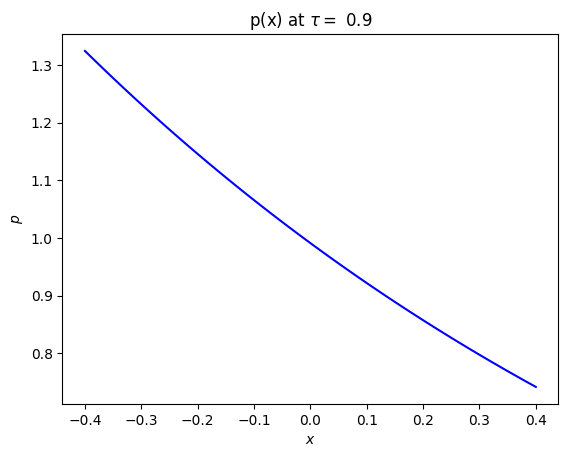

In [45]:
plot_frame(900)

In [54]:
def plot_coeff(tau_index):
    plt.plot(np.log10(np.abs(c[tau_index, :])), c='red')
    plt.xlabel(r'$k$')
    plt.ylabel(r'$log_{10}|c_k|$')
    plt.show()

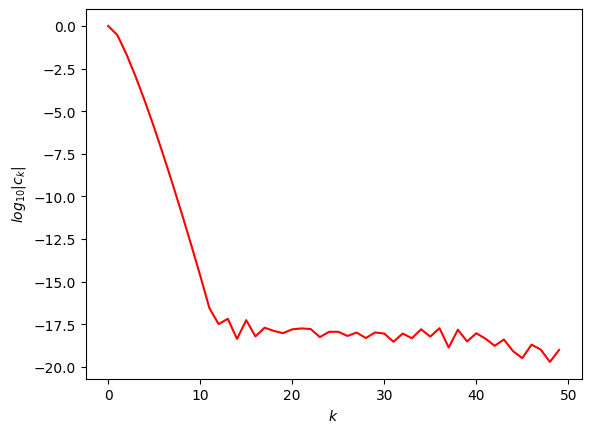

In [55]:
plot_coeff(901)

## Heatmap of Errors with Fixed N and Timestep

In [48]:
def r_to_xnum(r):
    return 1 + 2*(r - rmax)/(rmax - rmin)


In [49]:
# heatmap of errors

#pass in solution array

def vasicek_heatmap(c):

    numerical_solution = np.zeros((len(tau), len(xplot)))
    analytical_solution = np.zeros((len(tau), len(xplot)))

    for i in range(0, len(tau)):
            numerical_solution[i,:] = calc_u(c[i,:], xplot)
            analytical_solution[i,:] = vasicek_analytical(tau[i], alpha, mu, sig, xnum_to_r(xplot))

    errors = np.abs(numerical_solution - analytical_solution)

    return numerical_solution, errors

In [50]:
num_vasicek, errors_vasicek = vasicek_heatmap(c)

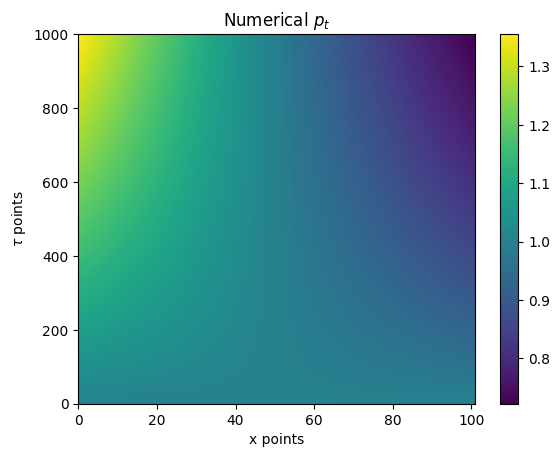

In [51]:
plt.pcolormesh(num_vasicek)
plt.title('Numerical '+r'$p_t$')
plt.xlabel('x points')
plt.ylabel(r'$\tau$'+' points')
plt.colorbar()

C:\Users\Ayush Roy\AppData\Local\Temp\ipykernel_15364\1758688211.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(np.log10(errors_vasicek))


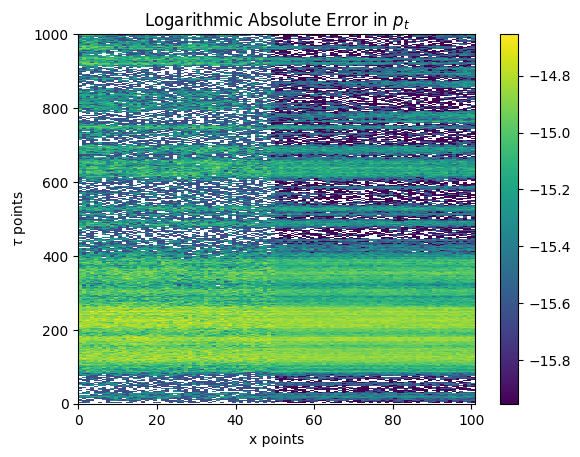

In [52]:
plt.pcolormesh(np.log10(errors_vasicek))
plt.title('Logarithmic Absolute Error in '+r'$p_t$')
plt.xlabel('x points')
plt.ylabel(r'$\tau$'+' points')
plt.colorbar()